In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
import lightgbm as lgb
import optuna
import os
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
np.random.seed(42)
os.makedirs('../report/images', exist_ok=True)
os.makedirs('../models', exist_ok=True)

from src.preprocessing import load_data, split_data, scale_features, add_row_statistics, FEATURE_COLS, TARGET_COL
from src.modeling import evaluate, save_model, build_results_table

In [2]:
train_raw = load_data('../data/raw/train.csv')

X_train, X_val, X_test, y_train, y_val, y_test = split_data(train_raw, val_size=0.1, test_size=0.1, seed=42)
X_tr_s, X_val_s, X_test_s, _ = scale_features(X_train, X_val, X_test)

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}')

train: (160000, 200), val: (20000, 200), test: (20000, 200)


### Feature engineering

In [16]:
X_train_aug = add_row_statistics(X_train)
X_val_aug   = add_row_statistics(X_val)
X_test_aug  = add_row_statistics(X_test)

print('raw features:', X_train.shape[1], 'with row stats:', X_train_aug.shape[1])

raw features: 200 with row stats: 205


### PCA — уменьшение размерности

,n_components,explained_var%,val_roc_auc
0,50,26.2,0.8537
1,100,51.5,0.8552
2,150,76.1,0.8560
3,200,100.0,0.8562


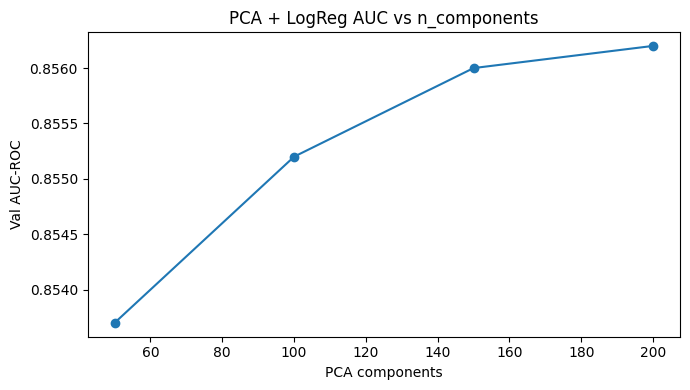

In [4]:
X_tr_s, X_val_s, X_test_s, _ = scale_features(X_train, X_val, X_test)

pca_results = []
for n in [50, 100, 150, 200]:
    if n < 200:
        pca = PCA(n_components=n, random_state=42)
        Xtr = pca.fit_transform(X_tr_s)
        Xvl = pca.transform(X_val_s)
        var = pca.explained_variance_ratio_.sum()
    else:
        Xtr, Xvl, var = X_tr_s, X_val_s, 1.0

    m = LogisticRegression(C=1.0, max_iter=500, class_weight='balanced', random_state=42, n_jobs=-1)
    m.fit(Xtr, y_train)
    auc = evaluate(m, Xvl, y_val)['roc_auc']
    pca_results.append({'n_components': n, 'explained_var%': round(var*100, 1), 'val_roc_auc': auc})

pca_df = pd.DataFrame(pca_results)
display(pca_df)

plt.figure(figsize=(7, 4))
plt.plot(pca_df['n_components'], pca_df['val_roc_auc'], 'o-')
plt.xlabel('PCA components'); plt.ylabel('Val AUC-ROC')
plt.title('PCA + LogReg AUC vs n_components')
plt.tight_layout()
plt.savefig('../report/images/pca_auc.png', dpi=120, bbox_inches='tight')
plt.show()

### Random Forest

In [5]:
rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_val  = evaluate(rf, X_val,  y_val)
rf_test = evaluate(rf, X_test, y_test)
print('RF val: ', rf_val)
print('RF test:', rf_test)
save_model(rf, '../models/random_forest.pkl')

RF val:  {'roc_auc': 0.7943, 'avg_precision': 0.373, 'f1': 0.382, 'accuracy': 0.8083}
RF test: {'roc_auc': 0.7897, 'avg_precision': 0.3526, 'f1': 0.3671, 'accuracy': 0.8058}


### XGBoost

In [6]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos, eval_metric='auc',
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

xgb_val  = evaluate(xgb_model, X_val,  y_val)
xgb_test = evaluate(xgb_model, X_test, y_test)
print('XGB val: ', xgb_val)
print('XGB test:', xgb_test)
save_model(xgb_model, '../models/xgboost.pkl')

XGB val:  {'roc_auc': 0.8765, 'avg_precision': 0.5552, 'f1': 0.4831, 'accuracy': 0.8439}
XGB test: {'roc_auc': 0.8729, 'avg_precision': 0.5369, 'f1': 0.4762, 'accuracy': 0.8405}


### LightGBM

In [7]:
lgbm = lgb.LGBMClassifier(
    n_estimators=500, num_leaves=31, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos, random_state=42, n_jobs=-1, verbose=-1
)
lgbm.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.log_evaluation(-1)])

lgbm_val  = evaluate(lgbm, X_val,  y_val)
lgbm_test = evaluate(lgbm, X_test, y_test)
print('LGBM val: ', lgbm_val)
print('LGBM test:', lgbm_test)

LGBM val:  {'roc_auc': 0.8892, 'avg_precision': 0.5926, 'f1': 0.5009, 'accuracy': 0.8518}
LGBM test: {'roc_auc': 0.8846, 'avg_precision': 0.5698, 'f1': 0.4968, 'accuracy': 0.8518}


### Optuna — перебор гиперпараметров LightGBM

In [8]:
def objective(trial):
    p = {
        'n_estimators':      trial.suggest_int('n_estimators', 300, 1000),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'scale_pos_weight': scale_pos, 'random_state': 42, 'n_jobs': -1, 'verbose': -1,
    }
    m = lgb.LGBMClassifier(**p)
    m.fit(X_train, y_train, callbacks=[lgb.log_evaluation(-1)])
    return roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'best AUC: {study.best_value:.4f}')
study.best_params

  0%|          | 0/50 [00:00<?, ?it/s]

best AUC: 0.8931


{'n_estimators': 932,
 'num_leaves': 39,
 'learning_rate': 0.03142120983273106,
 'subsample': 0.5647617386967987,
 'colsample_bytree': 0.9060227037917947,
 'min_child_samples': 17,
 'reg_alpha': 0.47823802717258546,
 'reg_lambda': 0.028068782689895214}

In [9]:
best = {**study.best_params, 'scale_pos_weight': scale_pos, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}

lgbm_tuned = lgb.LGBMClassifier(**best)
lgbm_tuned.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.log_evaluation(-1)])

lgbm_tuned_val  = evaluate(lgbm_tuned, X_val,  y_val)
lgbm_tuned_test = evaluate(lgbm_tuned, X_test, y_test)
print('LGBM tuned val: ', lgbm_tuned_val)
print('LGBM tuned test:', lgbm_tuned_test)
save_model(lgbm_tuned, '../models/lgbm_tuned.pkl')

LGBM tuned val:  {'roc_auc': 0.8931, 'avg_precision': 0.5979, 'f1': 0.5226, 'accuracy': 0.8682}
LGBM tuned test: {'roc_auc': 0.8862, 'avg_precision': 0.5741, 'f1': 0.5175, 'accuracy': 0.8674}


### Voting Ensemble

In [10]:
voting = VotingClassifier(
    estimators=[
        ('lr',   LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)),
        ('rf',   RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)),
        ('lgbm', lgb.LGBMClassifier(n_estimators=300, num_leaves=31, learning_rate=0.05, scale_pos_weight=scale_pos, random_state=42, verbose=-1)),
    ],
    voting='soft', n_jobs=-1
)
voting.fit(X_train, y_train)

voting_val  = evaluate(voting, X_val,  y_val)
voting_test = evaluate(voting, X_test, y_test)
print('Voting val: ', voting_val)
print('Voting test:', voting_test)
save_model(voting, '../models/voting_ensemble.pkl')

Voting val:  {'roc_auc': 0.8812, 'avg_precision': 0.5634, 'f1': 0.4704, 'accuracy': 0.8288}
Voting test: {'roc_auc': 0.8794, 'avg_precision': 0.5496, 'f1': 0.4685, 'accuracy': 0.8276}


### Stacking Ensemble

In [11]:
stacking = StackingClassifier(
    estimators=[
        ('xgb',  xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                    scale_pos_weight=scale_pos, random_state=42, verbosity=0, n_jobs=-1)),
        ('lgbm', lgb.LGBMClassifier(n_estimators=200, num_leaves=31, learning_rate=0.05,
                                     scale_pos_weight=scale_pos, random_state=42, verbose=-1, n_jobs=-1)),
        ('rf',   RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced',
                                        random_state=42, n_jobs=-1)),
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=500, random_state=42),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)
stacking.fit(X_train, y_train)

stacking_val  = evaluate(stacking, X_val,  y_val)
stacking_test = evaluate(stacking, X_test, y_test)
print('Stacking val: ', stacking_val)
print('Stacking test:', stacking_test)
save_model(stacking, '../models/stacking_ensemble.pkl')

Stacking val:  {'roc_auc': 0.8686, 'avg_precision': 0.532, 'f1': 0.4217, 'accuracy': 0.9171}
Stacking test: {'roc_auc': 0.8663, 'avg_precision': 0.5234, 'f1': 0.4185, 'accuracy': 0.916}


### Таблица экспериментов

In [12]:
lr_base = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
lr_base.fit(X_tr_s, y_train)
lr_val  = evaluate(lr_base, X_val_s,  y_val)
lr_test = evaluate(lr_base, X_test_s, y_test)

records = [
    {'model': 'Logistic Regression', 'val_roc_auc': lr_val['roc_auc'],         'val_ap': lr_val['avg_precision'],         'test_roc_auc': lr_test['roc_auc']},
    {'model': 'Random Forest',       'val_roc_auc': rf_val['roc_auc'],         'val_ap': rf_val['avg_precision'],         'test_roc_auc': rf_test['roc_auc']},
    {'model': 'XGBoost',             'val_roc_auc': xgb_val['roc_auc'],        'val_ap': xgb_val['avg_precision'],        'test_roc_auc': xgb_test['roc_auc']},
    {'model': 'LightGBM',            'val_roc_auc': lgbm_val['roc_auc'],       'val_ap': lgbm_val['avg_precision'],       'test_roc_auc': lgbm_test['roc_auc']},
    {'model': 'LightGBM (Optuna)',   'val_roc_auc': lgbm_tuned_val['roc_auc'], 'val_ap': lgbm_tuned_val['avg_precision'], 'test_roc_auc': lgbm_tuned_test['roc_auc']},
    {'model': 'Voting',              'val_roc_auc': voting_val['roc_auc'],     'val_ap': voting_val['avg_precision'],     'test_roc_auc': voting_test['roc_auc']},
    {'model': 'Stacking',            'val_roc_auc': stacking_val['roc_auc'],   'val_ap': stacking_val['avg_precision'],   'test_roc_auc': stacking_test['roc_auc']},
]

results_df = build_results_table(records)
display(results_df)
results_df.to_csv('../report/experiments_table.csv', index=False)

,model,val_roc_auc,val_ap,test_roc_auc
0,LightGBM (Optuna),0.8931,0.5979,0.8862
1,LightGBM,0.8892,0.5926,0.8846
2,Voting,0.8812,0.5634,0.8794
3,XGBoost,0.8765,0.5552,0.8729
4,Stacking,0.8686,0.5320,0.8663
5,Logistic Regression,0.8562,0.5007,0.8548
6,Random Forest,0.7943,0.3730,0.7897


### ROC кривые всех моделей

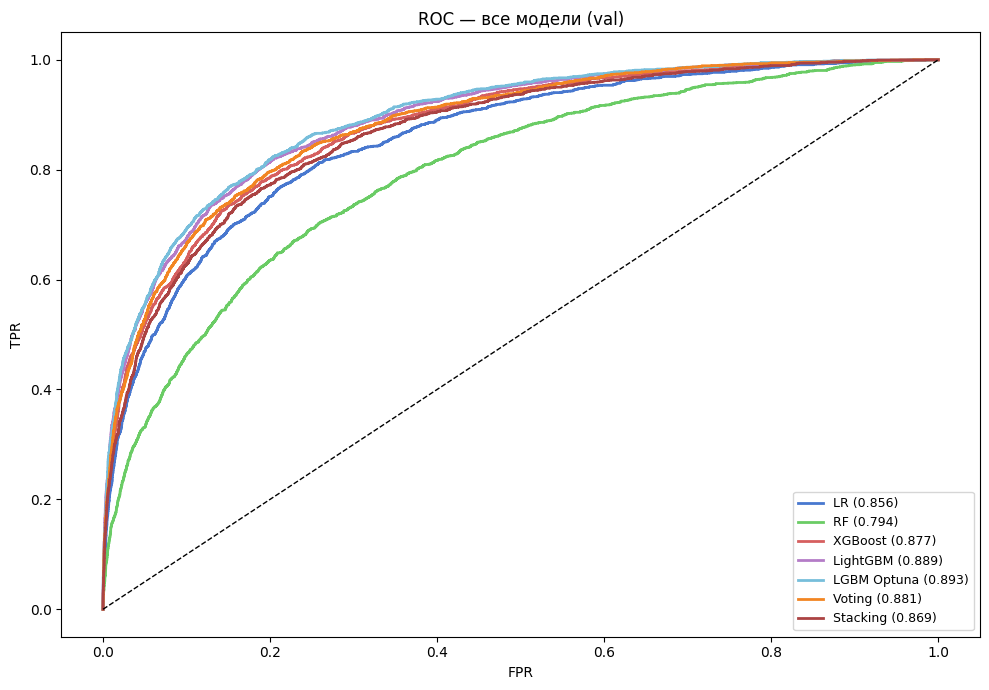

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))

models_list = [
    ('LR',          lr_base,    X_val_s, y_val, '#4878CF'),
    ('RF',          rf,         X_val,   y_val, '#6ACC65'),
    ('XGBoost',     xgb_model,  X_val,   y_val, '#D65F5F'),
    ('LightGBM',    lgbm,       X_val,   y_val, '#B47CC7'),
    ('LGBM Optuna', lgbm_tuned, X_val,   y_val, '#77BEDB'),
    ('Voting',      voting,     X_val,   y_val, '#F28522'),
    ('Stacking',    stacking,   X_val,   y_val, '#AB4343'),
]

from sklearn.metrics import auc as sk_auc
for name, model, Xv, yv, color in models_list:
    p = model.predict_proba(Xv)[:, 1]
    fpr, tpr, _ = roc_curve(yv, p)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} ({sk_auc(fpr,tpr):.3f})')

ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — все модели (val)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../report/images/all_models_roc.png', dpi=120, bbox_inches='tight')
plt.show()

### Feature importance

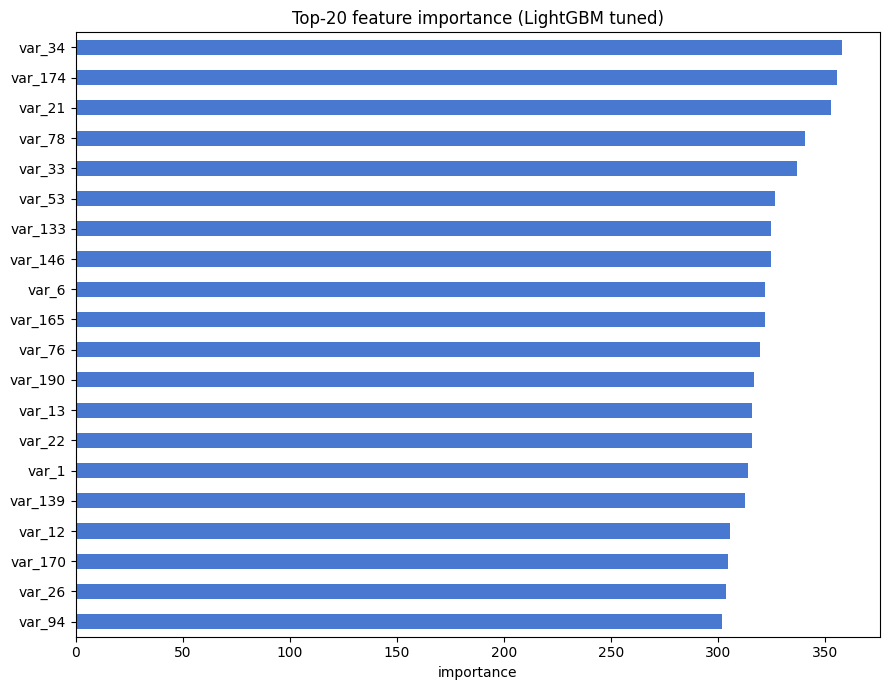

In [14]:
fi = pd.Series(lgbm_tuned.feature_importances_, index=FEATURE_COLS).nlargest(20).sort_values()

plt.figure(figsize=(9, 7))
fi.plot(kind='barh', color='#4878CF')
plt.title('Top-20 feature importance (LightGBM tuned)')
plt.xlabel('importance')
plt.tight_layout()
plt.savefig('../report/images/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
print('final model: LightGBM (Optuna tuned)')
print('val  AUC:', lgbm_tuned_val['roc_auc'])
print('test AUC:', lgbm_tuned_test['roc_auc'])
print(f'improvement over LR baseline: +{lgbm_tuned_test["roc_auc"] - lr_test["roc_auc"]:.4f}')

final model: LightGBM (Optuna tuned)
val  AUC: 0.8931
test AUC: 0.8862
improvement over LR baseline: +0.0314
